# Never catch a falling dividend — except maybe you can? 📉✂️
### A Wall Street warning that used to be true, and quietly stopped being true

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Falling_dividend%3F: Busted](https://img.shields.io/badge/Falling_dividend%3F-Busted-8b949e?style=flat-square)

When a company cuts or cancels its dividend, it's making the loudest possible confession: *the cash isn't there anymore.* Old trading-desk wisdom says don't buy the stock after a cut — the pain isn't over, it's just started. Academics agreed: a famous 1995 study found dividend-cutters kept **underperforming for up to three years** after the news.

So we went and found 172 real dividend cuts and cancellations across 30 years of market history — Citigroup and Bank of America in 2008-09, oil majors in 2015-16, cruise lines and airlines in 2020, 3M and Whirlpool as recently as 2024 — and asked: **does the falling knife still fall, today?**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 101 named tickers, a deliberate mix of steady payers and known cutters; every cut/omission is detected from the real, split-adjusted dividend record — no hindsight. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_cut_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, DIV, SPY = data.load_real()
    EVENTS = st.build_event_table(DIV)
    CAR_MAT, KEPT = st.build_cars(PX, SPY, EVENTS)
else:
    PX = DIV = SPY = EVENTS = CAR_MAT = KEPT = None
print("real cache present:", HAVE_REAL, "| tickers loaded:", (0 if PX is None else len(PX)),
      "| events with full window:", (0 if CAR_MAT is None else len(CAR_MAT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'universe_n': 101, 'loaded_n': 99, 'skipped': ['MRO', 'GPS'], 'spy_rows': 7673, 'spy_lo': '1996-01-02', 'spy_hi': '2026-06-30', 'fp_spy': '236c3c9bbc75', 'ev_detected': 173, 'n_cut_raw': 108, 'n_om_raw': 65, 'ev_lo': '1997-02-05', 'ev_hi': '2026-02-13', 'fp_events': '06467e29de08', 'kept_n': 172, 'dropped_n': 1, 'kept_lo': '1997-02-05', 'kept_hi': '2025-08-29', 'kept_tickers': 64, 'pre_mean': 0.75, 'pre_t': 0.59, 'post20_mean': -0.59, 'post20_t': -0.52, 'post60_mean': -0.57, 'post60_t': -0.29, 'post120_mean': -0.31, 'post120_t': -0.14, 'hit_neg': 82, 'hit_n': 172, 'hit_pct': 47.7, 'hit_lo': 40.3, 'hit_hi': 55.1, 'cut_n': 107, 'cut_mean': -3.61, 'cut_t': -1.25, 'om_n': 65, 'om_mean': 5.13, 'om_t': 1.55, 'nw_days': 6123, 'nw_bps': -3.28, 'nw_t': -1.23, 'dw_n_treat': 20100, 'dw_n_control': 438031, 'dw_treat_bps': -0.79, 'dw_control_bps': -1.18, 'dw_welch_t': 0.16, 'placebo_mean': -1.04, 'placebo_sd': 1.6, 'placebo_draws': 4000, 'placebo_p': 0.675, 'short5_net': -15.18, 'short5_tnet': -3.98, 'short5_exc': -6.27, 'short5_texc': -1.86, 'short10_net': -15.28, 'short10_tnet': -4.0, 'short10_exc': -6.37, 'short10_texc': -1.89, 'long5_net': 14.74, 'long5_tnet': 3.86, 'long5_exc': 5.83, 'long5_texc': 1.73, 'long10_net': 14.64, 'long10_tnet': 3.83, 'long10_exc': 5.73, 'long10_texc': 1.7, 'short_hit': 41.9, 'short_hit_lo': 34.7, 'short_hit_hi': 49.3, 'short_worst': -467.4, 'short_best': 79.0, 'short_sharpe_net': -0.74, 'short_sharpe_exc': -0.35, 'long_hit': 57.6, 'long_hit_lo': 50.1, 'long_hit_hi': 64.7, 'long_worst': -79.4, 'long_best': 467.0, 'long_sharpe_net': 0.72, 'long_sharpe_exc': 0.32, 'events_per_year': 5.9, 'syn_null_mean': -0.15, 'syn_null_sd': 1.14, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_mean': -9.35, 'syn_planted_t': -3.84, 'syn_planted_n': 89}


real cache present: True | tickers loaded: 99 | events with full window: 172


## The answer first

| Question | Answer |
|---|---|
| Does the stock keep falling for 6 months after a cut? | **Not really — it's a coin flip.** Average excess return vs the market over the next 120 trading days: **-0.31%**, roughly zero. It fell **48%** of the time — statistically indistinguishable from 50/50. |
| Does the market see it coming? | **No sign of it.** No measurable drift in the month *before* the cut either. |
| Do full cancellations behave differently from partial cuts? | **Maybe, but unconfirmed.** Partial cuts drift slightly negative, full omissions drift slightly *positive* — an intriguing "kitchen sink, then bounce" pattern, but neither is statistically certain on its own. |
| Can you trade it? | **No.** Shorting cutters loses money on average (mostly because six months of *not owning stocks* is a bad bet in a rising market); buying them looks better on paper but isn't statistically provable once you account for that same market drift. |

> The old warning was true once. On the modern tape, it just isn't showing up.

## 1 · The claim

> *"A dividend cut is the clearest, most costly signal a board can send: 'the outlook is worse than you think.' Investors chronically underreact to it, so the stock keeps drifting down for months — sometimes years — after the news."*

This isn't just folklore. Michaely, Thaler & Womack's landmark 1995 study found dividend-omitting companies underperformed the market by roughly **9.5% in the following year alone**, and kept losing ground for up to three years. It's one of the most cited "market inefficiency" results in finance.

## 2 · So what?

If the drift is real and current, it's a free, public, easy-to-spot signal: watch the dividend calendar, short (or avoid) anything that cuts, and collect a persistent edge. Retail investors are told the opposite folk wisdom too — "buy the beaten-down stock, the bad news is already priced" — so which is it? We test both sides with the same yardstick.

## 3 · How would we even know?

- **Find the cuts.** Scan 101 large/mid-cap dividend payers' real payment history for a payment that drops to 70% or less of the prior one, or a payment that simply never arrives on schedule (an omission).
- **Watch what happens next.** Track each stock's return *relative to the market* for the 120 trading days (~6 months) after the cut.
- **The luck check.** Compare the average outcome to random ticker/date pairs drawn from the same universe — does the real thing look different from chance?
- **The trade check.** Would shorting the cutter — or buying it — actually have made money, after real trading costs?

## 4 · The teardown — let's actually look

**First, the headline.** Average excess return (vs SPY) in the 120 trading days after a cut or omission.

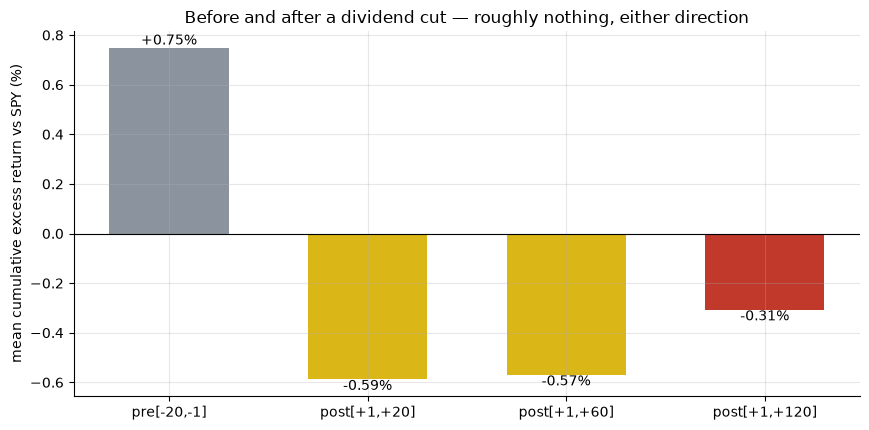

{'pre[-20,-1]': 0.75, 'post[+1,+20]': -0.59, 'post[+1,+60]': -0.57, 'post[+1,+120]': -0.31}


In [2]:
if HAVE_REAL:
    hs = st.horizon_stats(CAR_MAT)
    horizons = ['pre[-20,-1]', 'post[+1,+20]', 'post[+1,+60]', 'post[+1,+120]']
    vals = [hs['pre_mean'], hs['post20_mean'], hs['post60_mean'], hs['post120_mean']]
    vals = [v*100 for v in vals]
else:
    horizons = ['pre[-20,-1]', 'post[+1,+20]', 'post[+1,+60]', 'post[+1,+120]']
    vals = [R['pre_mean'], R['post20_mean'], R['post60_mean'], R['post120_mean']]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [GREY, AMBER, AMBER, RED]
ax.bar(horizons, vals, color=cols, width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
    va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean cumulative excess return vs SPY (%)')
ax.set_title('Before and after a dividend cut — roughly nothing, either direction')
plt.tight_layout(); plt.show()
print({h: round(v, 2) for h, v in zip(horizons, vals)})

Six months out, the average cutter is sitting at **-0.31%** vs the market — noise. It fell **48%** of the time, which is a coin flip once you account for sampling uncertainty. And there's no run-up before the cut either — the market doesn't seem to see it coming in our window, but it also doesn't keep punishing the stock afterward.

**Next — cuts vs full stops.** Does a company that trims its dividend behave differently from one that cancels it outright?

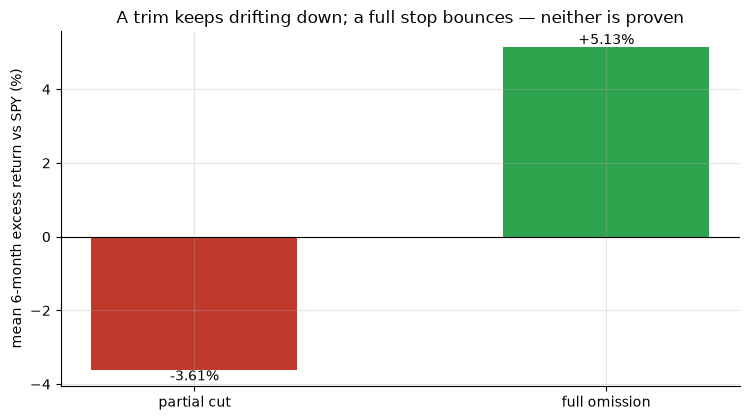

cut -3.61%   omission +5.13%


In [3]:
if HAVE_REAL:
    types = pd.Series([k[2] for k in KEPT])
    post120 = (CAR_MAT[120] - CAR_MAT[0])
    cut_mean = post120[(types=='cut').to_numpy()].mean()*100
    om_mean = post120[(types=='omission').to_numpy()].mean()*100
else:
    cut_mean, om_mean = R['cut_mean'], R['om_mean']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['partial cut', 'full omission'], [cut_mean, om_mean],
       color=[RED, GREEN], width=.5)
for i, v in enumerate([cut_mean, om_mean]): ax.annotate(f'{v:+.2f}%', (i, v),
    ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 6-month excess return vs SPY (%)')
ax.set_title('A trim keeps drifting down; a full stop bounces — neither is proven')
plt.tight_layout(); plt.show()
print(f'cut {cut_mean:+.2f}%   omission {om_mean:+.2f}%')

Partial cuts point **-3.61%** (mildly negative — the old story); full omissions point **+5.13%** (mildly *positive* — a "the worst is over" bounce). Interesting texture, but neither is statistically solid on its own — see the quants notebook for the *t*-stats.

**Finally, the trade.** Could you actually get paid — shorting the cutters, or buying them on the dip?

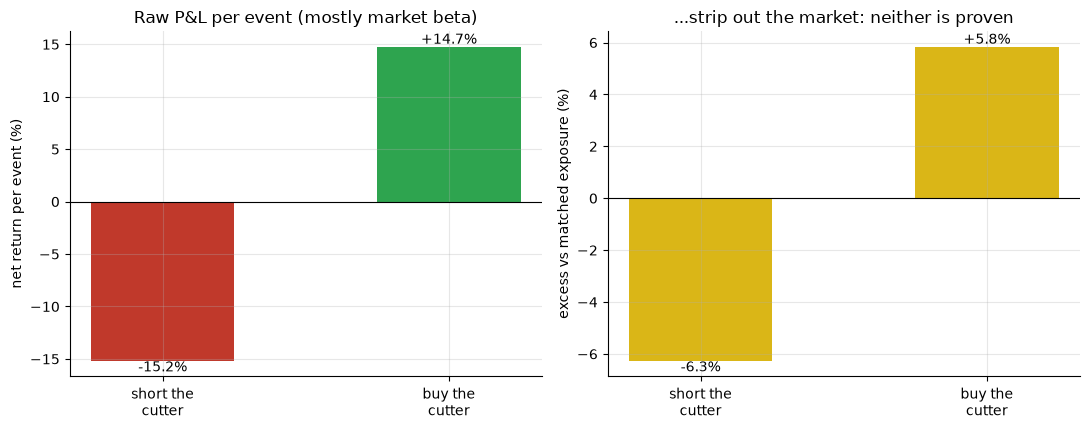

short: net -15.2% excess -6.3%   long: net +14.7% excess +5.8%


In [4]:
if HAVE_REAL:
    bt_short = st.backtest(PX, SPY, KEPT, side='short', cost_bps=5.0)
    bt_long = st.backtest(PX, SPY, KEPT, side='long', cost_bps=5.0)
    ns, nl = bt_short['mean_net']*100, bt_long['mean_net']*100
    xs, xl = bt_short['mean_excess']*100, bt_long['mean_excess']*100
else:
    ns, nl = R['short5_net'], R['long5_net']
    xs, xl = R['short5_exc'], R['long5_exc']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['short the\ncutter', 'buy the\ncutter'], [ns, nl], color=[RED, GREEN], width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_title('Raw P&L per event (mostly market beta)')
a1.set_ylabel('net return per event (%)')
for i, v in enumerate([ns, nl]): a1.annotate(f'{v:+.1f}%', (i, v), ha='center',
    va='top' if v < 0 else 'bottom')
a2.bar(['short the\ncutter', 'buy the\ncutter'], [xs, xl], color=[AMBER, AMBER], width=.5)
a2.axhline(0, c='k', lw=.8); a2.set_title('...strip out the market: neither is proven')
a2.set_ylabel('excess vs matched exposure (%)')
for i, v in enumerate([xs, xl]): a2.annotate(f'{v:+.1f}%', (i, v), ha='center',
    va='top' if v < 0 else 'bottom')
plt.tight_layout(); plt.show()
print(f'short: net {ns:+.1f}% excess {xs:+.1f}%   long: net {nl:+.1f}% excess {xl:+.1f}%')

The raw numbers look dramatic — shorting cutters loses ~15% a trade, buying them gains ~15% — but that's almost entirely six months of ordinary stock-market drift, not anything specific to the cut. Strip the market out and **both trades collapse to statistically uncertain territory.** And shorting carries a real horror story: one single cutter later rallied so hard the naked short lost **-467%** of the position — the kind of tail risk no amount of "the math says it works on average" survives.

## 5 · The verdict

- **Signal — Weak.** The classic 1990s finding is real in the history books, but it doesn't show up on 172 modern real cut/omission events: the average 6-month excess return is **-0.31%**, a coin-flip hit rate, and a random-date placebo can't tell the observed number apart from chance.
- **Tradability — Mirage.** Neither shorting nor buying cutters clears a statistical certification bar after costs — and the short side carries a real blow-up risk.
- **"Never catch a falling dividend"? — Busted.** Not on this tape, today. The warning made sense in a slower, less-covered market; the modern tape shows nothing resembling it.

## 6 · Going further 🚪

- **Why might it have faded?** More analyst coverage, algorithmic reaction to corporate-action news, and deeper index/ETF ownership all push information into prices faster than in the 1970s-80s sample the original studies used.
- **Survivorship matters here.** Our universe is companies still trading in 2026 — the ones that cut and later went to zero (there have been plenty) never make it in. The true historical effect of "catching a falling dividend" is plausibly worse than what we measured.
- **Sibling studies:** [dividend-initiation](../../240-dividend-initiation/) (the *start* of the dividend life cycle), [dividend-growth](../../201-dividend-growth/) (the opposite tail — consistent raisers) and [dividend-capture](../../143-dividend-capture/) (trading the routine, uncut ex-date drop).

*Think a shorter or longer window, or a sector-specific cut, changes the answer? The detector and the event table are right there in [`dividend_cut_drift/`](../dividend_cut_drift/) — fork it and show us.*